In [1]:
!pip install -q transformers peft bitsandbytes datasets accelerate trl

In [2]:
from google.colab import files
import os

os.makedirs("/content/mistral-adapter", exist_ok=True)
uploaded = files.upload()  # 选择本地的 adapter_model.safetensors 和 adapter_config.json

for fname in uploaded:
    os.rename(fname, f"/content/mistral-adapter/{fname}")

print(os.listdir("/content/mistral-adapter"))

Saving adapter_config.json to adapter_config.json
Saving adapter_model.safetensors to adapter_model.safetensors
['adapter_model.safetensors', 'adapter_config.json']


In [3]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, BitsAndBytesConfig

model_name = "mistralai/Mistral-7B-v0.1"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    quantization_config=bnb_config,
    device_map="auto",
)

print(f"Model loaded.")
print(f"GPU memory: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

MistralForSequenceClassification LOAD REPORT from: mistralai/Mistral-7B-v0.1
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded.
GPU memory: 3.86 GB


In [4]:
import transformers, peft, bitsandbytes, accelerate
print(f"transformers: {transformers.__version__}")
print(f"peft: {peft.__version__}")
print(f"bitsandbytes: {bitsandbytes.__version__}")
print(f"accelerate: {accelerate.__version__}")

transformers: 5.0.0
peft: 0.18.1
bitsandbytes: 0.49.2
accelerate: 1.13.0


In [5]:
from peft import PeftModel

model = PeftModel.from_pretrained(model, "/content/mistral-adapter")
model.eval()

print(type(model))
print(f"GPU memory after adapter: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

/usr/local/lib/python3.12/dist-packages/peft/config.py:220: UserWarning: Unexpected keyword arguments ['lora_ga_config', 'use_bdlora'] for class LoraConfig, these are ignored. This probably means that you're loading a configuration file that was saved using a higher version of the library and additional parameters have been introduced since. It is highly recommended to upgrade the PEFT version before continuing (e.g. by running `pip install -U peft`).
  warnings.warn(


<class 'peft.peft_model.PeftModelForSequenceClassification'>
GPU memory after adapter: 3.89 GB


In [6]:
import json

with open("/content/mistral-adapter/adapter_config.json") as f:
    config = json.load(f)
print(json.dumps(config, indent=2))

{
  "alora_invocation_tokens": null,
  "alpha_pattern": {},
  "arrow_config": null,
  "auto_mapping": null,
  "base_model_name_or_path": "mistralai/Mistral-7B-v0.1",
  "bias": "none",
  "corda_config": null,
  "ensure_weight_tying": false,
  "eva_config": null,
  "exclude_modules": null,
  "fan_in_fan_out": false,
  "inference_mode": true,
  "init_lora_weights": true,
  "layer_replication": null,
  "layers_pattern": null,
  "layers_to_transform": null,
  "loftq_config": {},
  "lora_alpha": 32,
  "lora_bias": false,
  "lora_dropout": 0.05,
  "lora_ga_config": null,
  "megatron_config": null,
  "megatron_core": "megatron.core",
  "modules_to_save": [
    "classifier",
    "score"
  ],
  "peft_type": "LORA",
  "peft_version": "0.19.1",
  "qalora_group_size": 16,
  "r": 16,
  "rank_pattern": {},
  "revision": null,
  "target_modules": [
    "q_proj",
    "v_proj"
  ],
  "target_parameters": null,
  "task_type": "SEQ_CLS",
  "trainable_token_indices": null,
  "use_bdlora": null,
  "use_dora

In [7]:
from datasets import load_dataset

dataset = load_dataset("zeroshot/twitter-financial-news-sentiment")
val_dataset = dataset["validation"]

print(val_dataset)
print(val_dataset[0])

README.md: 0.00B [00:00, ?B/s]

sent_train.csv: 0.00B [00:00, ?B/s]

sent_valid.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/9543 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2388 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label'],
    num_rows: 2388
})
{'text': '$ALLY - Ally Financial pulls outlook https://t.co/G9Zdi1boy5', 'label': 0}


In [10]:
model.config.pad_token_id = tokenizer.pad_token_id
print(f"pad_token_id: {model.config.pad_token_id}")

pad_token_id: 2


In [11]:
import numpy as np
from torch.utils.data import DataLoader
from transformers import DataCollatorWithPadding

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=128, padding=False)

tokenized_val = val_dataset.map(tokenize, batched=True, remove_columns=["text"])
tokenized_val.set_format("torch")

collator = DataCollatorWithPadding(tokenizer)
loader = DataLoader(tokenized_val, batch_size=32, collate_fn=collator)

all_preds, all_labels = [], []

with torch.no_grad():
    for batch in loader:
        batch = {k: v.to(model.device) for k, v in batch.items()}
        labels = batch.pop("labels")
        outputs = model(**batch)
        preds = outputs.logits.argmax(dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

acc = (all_preds == all_labels).mean()
print(f"Overall accuracy: {acc:.4f}")

label_names = ["Bearish", "Bullish", "Neutral"]
for i, name in enumerate(label_names):
    mask = all_labels == i
    label_acc = (all_preds[mask] == all_labels[mask]).mean()
    print(f"  {name} (label {i}): {label_acc:.4f}  n={mask.sum()}")

Overall accuracy: 0.9146
  Bearish (label 0): 0.8790  n=347
  Bullish (label 1): 0.8589  n=475
  Neutral (label 2): 0.9393  n=1566


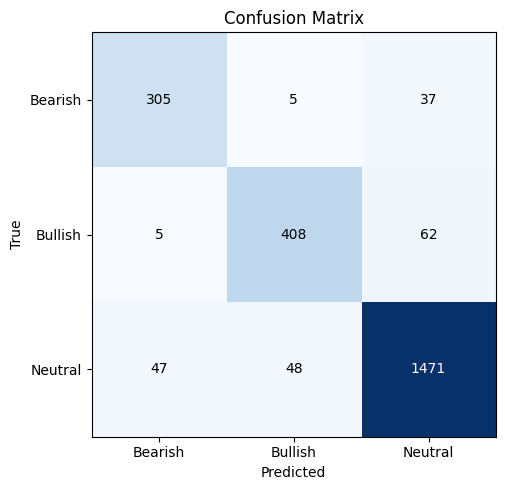

[[ 305    5   37]
 [   5  408   62]
 [  47   48 1471]]


In [12]:
import matplotlib.pyplot as plt
import numpy as np

label_names = ["Bearish", "Bullish", "Neutral"]
n = len(label_names)
cm = np.zeros((n, n), dtype=int)
for true, pred in zip(all_labels, all_preds):
    cm[true][pred] += 1

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(n)); ax.set_xticklabels(label_names)
ax.set_yticks(range(n)); ax.set_yticklabels(label_names)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion Matrix")

for i in range(n):
    for j in range(n):
        ax.text(j, i, cm[i][j], ha="center", va="center",
                color="white" if cm[i][j] > cm.max()*0.5 else "black")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120)
plt.show()
print(cm)

In [13]:
# 取几个典型的错误案例看一看
bearish_wrong = [(val_dataset[i]["text"], all_labels[i], all_preds[i])
                 for i in range(len(all_labels))
                 if all_labels[i] == 0 and all_preds[i] == 2][:5]

bullish_wrong = [(val_dataset[i]["text"], all_labels[i], all_preds[i])
                 for i in range(len(all_labels))
                 if all_labels[i] == 1 and all_preds[i] == 2][:5]

label_names = ["Bearish", "Bullish", "Neutral"]
print("=== 真实 Bearish 但预测为 Neutral ===")
for text, true, pred in bearish_wrong:
    print(f"  [{label_names[true]} → {label_names[pred]}] {text}")

print("\n=== 真实 Bullish 但预测为 Neutral ===")
for text, true, pred in bullish_wrong:
    print(f"  [{label_names[true]} → {label_names[pred]}] {text}")

=== 真实 Bearish 但预测为 Neutral ===
  [Bearish → Neutral] Central bank 'collateral damage' is skewing financial markets, one economist says https://t.co/sshC7mEqzk
  [Bearish → Neutral] Jerome Powell comes close to acknowledging that the Federal Reserve may not have the firepower to fight the next re… https://t.co/UD2rqlD6SD
  [Bearish → Neutral] No, The Fed Won't "Save The Market" - Here's Why  https://t.co/Ibq99qWSFz
  [Bearish → Neutral] Fiat Chrysler Relies on Ram Growth as Europe Losses Mount
  [Bearish → Neutral] Mahindra Says Coronavirus May Jeopardize India Emissions Rollout

=== 真实 Bullish 但预测为 Neutral ===
  [Bullish → Neutral] $KTOS: Kratos Defense and Security awarded a $39 million sole-source contract for Geolocation Global Support Servic… https://t.co/uPPTCX837l
  [Bullish → Neutral] 5 Reasons To Love Wendy's On Its 50th Birthday
  [Bullish → Neutral] AT&T says it will continue investing in Mexico: Mexican president
  [Bullish → Neutral] Boeing : Deliveries 24 Jets in November

In [15]:
import torch
import torch.nn.functional as F

test_texts = [
    "$AAPL hits all-time high as iPhone sales surge",
    "Company reports massive losses, stock plunges 20%",
    "Federal Reserve holds interest rates steady",
    "No, The Fed Won't \"Save The Market\" - Here's Why",
    "$KTOS awarded a $39 million sole-source contract",
]

label_names = ["Bearish", "Bullish", "Neutral"]

print(f"{'Text':<55} {'Pred':<10} {'Bearish':>8} {'Bullish':>8} {'Neutral':>8}")
print("-" * 95)

for text in test_texts:
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    with torch.no_grad():
        logits = model(**inputs).logits
    probs = F.softmax(logits.float(), dim=-1).cpu().numpy()[0]
#    probs = F.softmax(logits, dim=-1).cpu().numpy()[0]
    pred = label_names[probs.argmax()]
    short = text[:52] + "..." if len(text) > 52 else text
    print(f"{short:<55} {pred:<10} {probs[0]:>8.3f} {probs[1]:>8.3f} {probs[2]:>8.3f}")

Text                                                    Pred        Bearish  Bullish  Neutral
-----------------------------------------------------------------------------------------------
$AAPL hits all-time high as iPhone sales surge          Bullish       0.000    1.000    0.000
Company reports massive losses, stock plunges 20%       Bearish       1.000    0.000    0.000
Federal Reserve holds interest rates steady             Neutral       0.000    0.000    1.000
No, The Fed Won't "Save The Market" - Here's Why        Neutral       0.000    0.000    1.000
$KTOS awarded a $39 million sole-source contract        Neutral       0.000    0.000    1.000


In [16]:
import gc

del model
gc.collect()
torch.cuda.empty_cache()

print(f"GPU memory after release: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

GPU memory after release: 0.21 GB


In [17]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import torch

model_name = "mistralai/Mistral-7B-v0.1"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
)
base_model.eval()

print(f"GPU memory: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

GPU memory: 4.33 GB


In [18]:
from transformers import pipeline

pipe = pipeline(
    "text-generation",
    model=base_model,
    tokenizer=tokenizer,
    max_new_tokens=10,
)

test_texts = [
    "$AAPL hits all-time high as iPhone sales surge",
    "Company reports massive losses, stock plunges 20%",
    "Federal Reserve holds interest rates steady",
    "No, The Fed Won't \"Save The Market\" - Here's Why",
    "$KTOS awarded a $39 million sole-source contract",
]

prompt_template = """Classify the sentiment of this financial news as Bearish, Bullish, or Neutral.

Text: {text}
Sentiment:"""

print(f"{'Text':<55} {'Base Model Output'}")
print("-" * 90)

for text in test_texts:
    prompt = prompt_template.format(text=text)
    output = pipe(prompt, do_sample=False, pad_token_id=tokenizer.eos_token_id)
    generated = output[0]["generated_text"][len(prompt):].strip()
    short = text[:52] + "..." if len(text) > 52 else text
    print(f"{short:<55} {generated!r}")

Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'do_sample', 'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Text                                                    Base Model Output
------------------------------------------------------------------------------------------


Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


$AAPL hits all-time high as iPhone sales surge          'Bullish\n\nText: $AAPL'


Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Company reports massive losses, stock plunges 20%       'Bearish\n\nText: Company reports massive profits'


Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Federal Reserve holds interest rates steady             'Bullish\n\nText: Federal Reserve holds interest'


Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


No, The Fed Won't "Save The Market" - Here's Why        "Bullish\n\nText: The Fed's"
$KTOS awarded a $39 million sole-source contract        'Bullish\n\nText: $KTOS'
